### Solve cavity flow governed by Navier-Stokes equation. using PINNs (Under simple setting)
Goal : using PINNs, predicts $(\psi, p)$ for the input $(x,y)$


Classical Navier-Stokes equation in 2D, Incompressible Navier-Stokes equations with constant viscosity (ignore external force)
\begin{align}
\boldsymbol{u}_t + (\boldsymbol{u} \cdot \nabla)\boldsymbol{u} + \nabla p/\rho = \nu \nabla^2 \boldsymbol{u}\\
\nabla \cdot \boldsymbol{u} = 0, \quad \text{where} \quad \boldsymbol{u}\equiv(u,v)
\end{align}
If steady state $u_t = 0$
\begin{align}
u_x + v_y &= 0\\
u u_x + v u_y + p_x/\rho - \nu(u_{xx} + u_{yy}) &= 0\\
u v_x + v v_y + p_y/\rho - \nu(v_{xx} + v_{yy}) &= 0\\
\end{align}
boundary condition

$\{x,y\} \in \{0,1\}\times\{0,1\}$

$(u,v)=(1,0)$ for $y=0$ and $(u,v)=(0,0)$ for other boundaries.

For simplify, define stream function $ (u, v) = (\frac{\partial \psi}{\partial y}, -\frac{\partial \psi}{\partial x})$

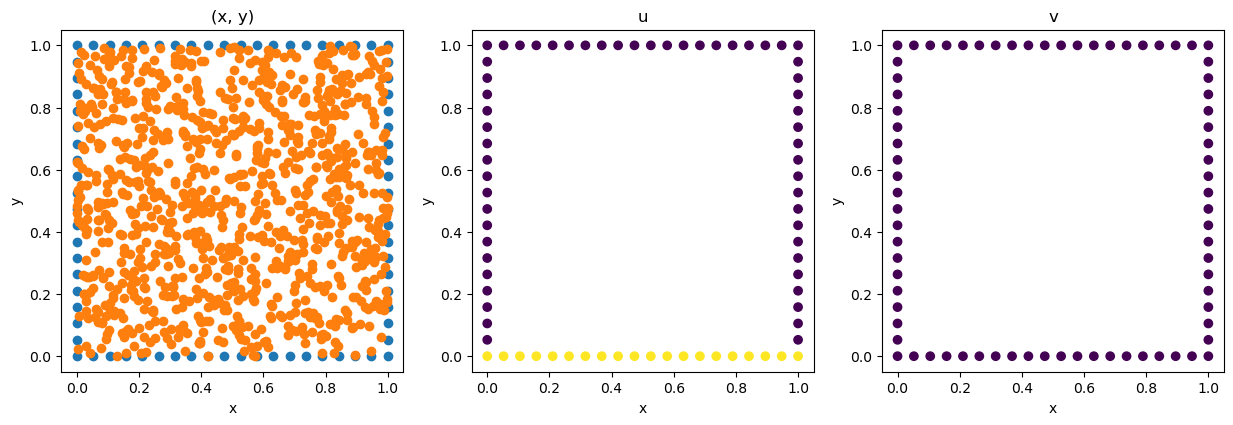

In [1]:
# YOUR CODE HERE (30pts)

# YOUR GENERATE TRAINING SET CODE HERE
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(1)


# Sampling domain points
N_bound = 20 # Number of smaple points at the boundary
N_bulk = 1000 # Number of smaple points in the bulk
r_bound = torch.zeros((4*N_bound-4, 2))
x = torch.linspace(0, 1, N_bound)
y = torch.linspace(0, 1, N_bound)

# y = 0
r_bound[:N_bound, 0] = x

# x = 1
r_bound[N_bound:2*N_bound-2, 0] = x[-1]
r_bound[N_bound:2*N_bound-2, 1] = y[1:-1]

# y = 1
r_bound[2*N_bound-2:3*N_bound-2, 0] = x
r_bound[2*N_bound-2:3*N_bound-2, 1] = y[-1]

# x = 0
r_bound[3*N_bound-2:4*N_bound-4, 1] = y[1:-1]

r_bound.requires_grad_(True)

# (x, y) in bulk
r_bulk = torch.rand((N_bulk, 2), requires_grad=True)

# Boundary condition for u, v
u_bound = torch.zeros((4*N_bound-4))
u_bound[:N_bound] = 1.0
v_bound = torch.zeros((4*N_bound-4))

plt.figure(figsize=(15, 45))

plt.subplot(1, 3, 1)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach())
plt.scatter(r_bulk[:, 0].detach(), r_bulk[:, 1].detach())
plt.title('(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 2)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach(), c=u_bound)
plt.title('u')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 3)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach(), c=v_bound)
plt.title('v')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.show()

In [2]:
# YOUR CODE HERE (30pts)

# YOUR NEURAL NETWORK DESIGN AND LOSS WITH RESIDUAL CODE HERE
torch.manual_seed(1)
PINN_net = nn.Sequential(
    # input: x, y
    # output: psi, p
    # If we consider psi, u_x+v_y = psi_xy - psi_yx = 0. Therefore, we don't need to consider Eq. (1)
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 2)
    )


def Residual(net, r_b, r, u_b, v_b, nu):
    '''
    net: Neural newtork
    r_b: (x, y) for boundary 
    r: (x, y) for bulk
    u_b: Boundary condition for u
    v_b: Boundary condition for v
    nu: PDE parameter

    Approach: Differentiate psi first, and fit boundary condition using u and v
    '''
    
    # At the boundary
    out_b = net(r_b)
    psi_b = out_b[:, 0]
    p_b = out_b[:, 1]
    dpsi_b = torch.autograd.grad(psi_b, r_b, grad_outputs=torch.ones_like(psi_b), create_graph=True)[0]
    u_b_pred = dpsi_b[:, 1]
    v_b_pred = -dpsi_b[:, 0]

    loss_b = ((u_b_pred.squeeze() - u_b)**2).mean() + ((v_b_pred.squeeze() - v_b)**2).mean()

    loss_p = ((p_b[0])**2).mean() # Gauge fixing of pressure

    loss_psi = (psi_b[0]**2).mean() # Gauge fixing of psi

    # At the bulk
    out = net(r)
    psi = out[:, 0] 
    p = out[:, 1]

    dpsi = torch.autograd.grad(psi, r, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    u = dpsi[:, 1]
    v = -dpsi[:, 0]

    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    ux = du[:, 0]
    uy = du[:, 1]
    uxx = torch.autograd.grad(ux, r, grad_outputs=torch.ones_like(ux), create_graph=True)[0][:, 0]
    uyy = torch.autograd.grad(uy, r, grad_outputs=torch.ones_like(uy), create_graph=True)[0][:, 1]

    dv = torch.autograd.grad(v, r, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    vx = dv[:, 0]
    vy = dv[:, 1]
    vxx = torch.autograd.grad(vx, r, grad_outputs=torch.ones_like(vx), create_graph=True)[0][:, 0]
    vyy = torch.autograd.grad(vy, r, grad_outputs=torch.ones_like(vy), create_graph=True)[0][:, 1]

    dp = torch.autograd.grad(p, r, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    px = dp[:, 0]
    py = dp[:, 1]


    loss_PDE = ((u*ux + v*uy + px - nu*(uxx + uyy))**2).mean() + ((u*vx + v*vy + py - nu*(vxx + vyy))**2).mean()

    loss = loss_b + loss_PDE + loss_p + loss_psi


    return loss

In [3]:
# YOUR CODE HERE (30pts)

# YOUR TRAINING NEURAL NETWORK CODE HERE
# TRAINING NEURAL NETWORK
epochs = 15000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(PINN_net.parameters(), lr=1e-3)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(PINN_net, r_bound, r_bulk, u_bound, v_bound, 1)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

Epoch 1000/15000, Loss: 0.038310956209897995
Epoch 2000/15000, Loss: 0.03050416335463524
Epoch 3000/15000, Loss: 0.029406221583485603
Epoch 4000/15000, Loss: 0.02878420241177082
Epoch 5000/15000, Loss: 0.028294453397393227
Epoch 6000/15000, Loss: 0.027922984212636948
Epoch 7000/15000, Loss: 0.02753116376698017
Epoch 8000/15000, Loss: 0.02716626599431038
Epoch 9000/15000, Loss: 0.02757096476852894
Epoch 10000/15000, Loss: 0.026461398229002953
Epoch 11000/15000, Loss: 0.02612367831170559
Epoch 12000/15000, Loss: 0.025796551257371902
Epoch 13000/15000, Loss: 0.028277110308408737
Epoch 14000/15000, Loss: 0.025031503289937973
Epoch 15000/15000, Loss: 0.02463376894593239


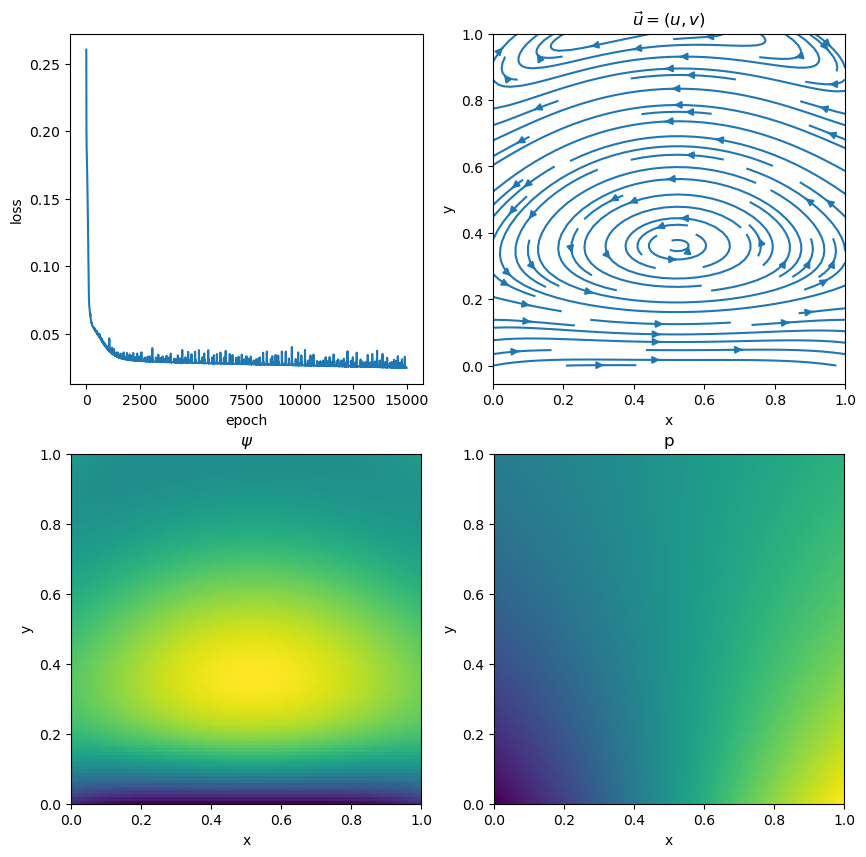

In [4]:
# VISUALIZATION (10pts)

# YOUR VISUALIZATION CODE HERE
PINN_net.eval()
x = torch.linspace(0, 1, 100)
y = torch.linspace(0, 1, 100)
X, Y = torch.meshgrid(x, y, indexing='xy')
r = torch.cat((X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1)
r.requires_grad_(True)

out = PINN_net(r)
psi = out[:, 0]
p = out[:, 1]

dpsi = torch.autograd.grad(psi, r, grad_outputs=torch.ones_like(psi), create_graph=False)[0]
u = dpsi[:, 1].detach().numpy().reshape(len(x), len(y))
v = -dpsi[:, 0].detach().numpy().reshape(len(x), len(y))

psi = psi.detach().numpy().reshape(len(x), len(y))
p = p.detach().numpy().reshape(len(x), len(y))
X = X.detach().numpy().reshape(len(x), len(y))
Y = Y.detach().numpy().reshape(len(x), len(y))

fig = plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.plot(loss_list)
plt.xlabel('epoch')
plt.ylabel('loss')

plt.subplot(222)
plt.title('$\\vec{u}=(u,v)$')
plt.xlabel('x')
plt.ylabel('y')
plt.streamplot(X, Y, u, v)

plt.subplot(223)
plt.title('$\psi$')
plt.xlabel('x')
plt.ylabel('y')
plt.imshow(psi, extent=[0, 1, 0,1], origin='lower')

plt.subplot(224)
plt.title('p')
plt.xlabel('x')
plt.ylabel('y')
plt.imshow(p, extent=[0, 1, 0,1], origin='lower')
plt.show()

